# SIGCTiArural — Benchmark V1 · Experimento M1_mobilenetv2_001

**Notebook oficial de investigación** para el primer entrenamiento del benchmark `agriculture_v2_baseline_v1`.

| Campo | Valor |
|---|---|
| **Proyecto** | SIGCTiArural (ecosistema vivo de conocimiento verificado) |
| **Dataset** | Dataset V2 Oficial Recuperado · `agriculture_images_tomato-potato-corn` v1 |
| **Corpus** | **22.488 imágenes · 16 clases · 3 especies** |
| **Modelo** | **MobileNetV2** (torchvision pretrained) — control clásico |
| **Run** | `M1_mobilenetv2_001` · seed **42** · split v1 (70/15/15) |
| **Tipo** | Saneo de pipeline + cota base (lower bound) de comparación |
| **Estado** | ✅ Diseñado y listo para ejecutar en Google Colab (NO entrenado aún) |
| **Honestidad** | Laboratorio controlado (PlantVillage `raw/color`). NO declara validez de campo. |

**Referencias:** `SIGCTIARURAL_BENCHMARK_V1_PLAN.md` · `SIGCTIARURAL_BENCHMARK_V1_EXECUTION_PLAYBOOK.md` · `baseline_experiment_manifest.agriculture_v2_baseline_v2.yaml` · `raw_source_manifest.agriculture_v2_dataset_v2.yaml`.

## 1. Dataset V2 Oficial Recuperado

**22.488 imágenes · 16 clases · 3 especies**, bootstrap de laboratorio desde PlantVillage `raw/color` (origen verificado `D:\RespaldoData\PlantVillage-Dataset`, repo oficial spMohanty).

### Especies

| Especie | Clases | Imágenes |
|---|---:|---:|
| Tomato | 9 | 16.484 |
| Potato | 3 | 2.152 |
| Corn | 4 | 3.852 |
| **Total** | **16** | **22.488** |

### Split oficial (`agriculture_v2_split_v1`, seed 42)

| Partición | Imágenes |
|---|---:|
| train | 15.741 |
| validation | 3.373 |
| test | 3.374 |
| **Total** | **22.488** |

### Desbalance (importante para el diseño)

- Clase mayoritaria: `tomato__yellow_leaf_curl_virus` (5.357)
- Clase minoritaria: `potato__healthy` (152)
- **Ratio min/max ≈ 35.24×** → se requiere loss ponderada + muestreo balanceado.

**Puntos que el notebook verificará al arrancar:** 16/16 clases en las tres particiones y conteos exactos (15.741 / 3.373 / 3.374).

## ETL — Extracción, Transformación y Carga (pipeline oficial)

El Dataset V2 oficial materializado sigue un ETL reproducible gobernado por manifiestos (fases B1–B5 del BUILD_PLAYBOOK):

| Etapa | Qué ocurre | Artefacto |
|---|---|---|
| **Extract** | Origen `D:\RespaldoData\PlantVillage-Dataset\raw\color` (54.305/38, repo spMohanty) → se copian SOLO las 16 clases del scope | `v1/RAW/` (22.488, read-only) |
| **Transform** | Renombre canónico · `labels_v1.csv` (8 campos) · dedup SHA-256 + pHash (anti-fuga) · split estratificado 70/15/15 seed 42 | `labels_v1.csv` · `split_lists/` |
| **Load (curated)** | Copiado físico train/validation/test según pertenencia + checksums | `v1/curated/` (22.488) |
| **Load (runtime)** | `ImageFolder` + aumentación + `DataLoader` (batch 64) en Colab | tensores (N,3,224,224) |

**Nota de honestidad:** ETL de laboratorio puro — los conteos (22.488/16/3) y CHECKSUMS quedaron congelados en el freeze oficial; el notebook verifica esas cifras al cargar.

## 2. Diseño experimental

### ¿Por qué MobileNetV2 primero? (rol: control)

1. **Saneo del pipeline**: costo computacional mínimo; si algo está mal (split, labels, fuga, balanceo) se detecta rápido y barato.
2. **Cota base / lower bound**: referencia clásica estable para comparar las 4 arquitecturas oficiales (EfficientNet-B0, MobileNetV3-Large, ResNet50, ConvNeXt-Tiny).
3. **Detección de fugas**: si un control produce macro-F1 ≈ 1.0 de forma sospechosa sobre validation, hay lógica de balanceo/pérdida de info — red flag.
4. **Decisión honesta**: con dataset de laboratorio saturado, la diferencia de F1 entre top arquitecturas suele ser pequeña; el factor de discriminación final será **macro-F1 + ECE + coste edge**, no F1 solo.

### Configuración canónica (idéntica a `benchmark/config.yaml`)

| Parámetro | Valor |
|---|---|
| batch_size | 64 |
| epochs | 40 (early stop patience 8, macro-F1 val) |
| optimizer | AdamW · lr 3e-4 · weight_decay 1e-4 |
| scheduler | CosineAnnealingLR (T_max=40, eta_min=lr·0.01) |
| loss | CrossEntropyLoss ponderada (w_c = N/(n_c·16)) |
| sampler | WeightedRandomSampler (balanceo por clase) |
| image_size | 224 (Resize 256 → crop) |
| fp16 AMP | Sí (autocast + GradScaler) |
| seed | 42 (pipeline + split) |
| transfer learning | pretrained ImageNet, head 16 clases |

## Hipótesis científicas

Marco hipotético-deductivo del experimento `M1_mobilenetv2_001`. Cada hipótesis es **falsable**: se enuncia con criterio de rechazo operativo y se decide contra las métricas sobre **validation** (nunca contra test durante el desarrollo).

| # | Hipótesis | Operacionalización | Criterio de rechazo |
|---|---|---|---|
| H1 | El control MobileNetV2, bajo la política canónica (seed 42, CE ponderada, WeightedRandomSampler, 40 epochs), alcanza un diagnóstico sano sobre validation. | macro-F1 val dentro del rango esperado 0.955–0.970 | macro-F1 val < 0.90 (bug/split) o ≈ 1.0 (fuga) |
| H2 | El pipeline es **fuga-free**: dedup SHA-256 + pHash y split estratificado 70/15/15 garantizan particiones disjuntas. | macro-F1 test ≈ macro-F1 val (± 0.02) en el single-use final | \|Δ macro-F1 (test−val)\| > 0.05 |
| H3 | El desbalance 35.24× (152→4.840) no degrada las clases minoritarias por debajo del umbral de utilidad gracias al balanceo ponderado. | F1 de las 4 minoritarias ≥ 0.85 (val) | alguna minoritaria con F1 < 0.80 |
| H4 | El control está **bien calibrado**: la confianza predicha refleja el error real en el agregado. | ECE val ≤ 0.10 (gate) | ECE val > 0.10 |
| H5 (benchmark) | En un dataset de laboratorio saturado, arquitecturas de mayor capacidad **no superarán** el macro-F1 del control en > 0.005; el factor de discriminación real será ECE + coste edge. | Δmacro-F1(arquitectura − control) medido en la comparativa | Δ > 0.005 sostenido en ≥ 2 arquitecturas |

**Aclaración:** H5 se decide en el benchmark completo (no en este run); aquí solo se fija la referencia `control` para el contraste.

## Variables experimentales

Clasificación del diseño según el tipo de variable (metodología experimental):

| Variable | Tipo | Papel en el experimento |
|---|---|---|
| **Arquitectura** (MobileNetV2 vs. EfficientNet-B0, MobileNetV3-Large, ResNet50, ConvNeXt-Tiny) | Independiente (nominal) | Tratamiento; este run ejecuta solo el nivel `control` |
| **macro-F1 (val/test)** | Dependiente (razón) | Medida primaria de desempeño per-clase |
| **ECE** | Dependiente (razón) | Medida de calibración agregada |
| **balanced_accuracy · macro-AUC · mAP** | Dependiente (razón) | Medidas secundarias de discriminación/ranking |
| **Seed 42 · transformaciones idénticas · política de optimización · particiones oficiales** | Controladas | Bloques constantes entre arquitecturas |
| **Pesos pretrained ImageNet** | De selección | Confusor real: transfiere conocimiento no atribuible a la arquitectura |
| **Fondo limpio / condiciones controladas del dataset** | De muestreo | Confusor externo: haría sobreestimar la generalización al campo |

**Regla de control:** ninguna métrica sobre test interviene en decisiones intermedias (early stopping, gate, selección de checkpoint), preservando la independencia de la medida final.

## Riesgos y sesgos

1. **Sesgo de dataset de laboratorio.** PlantVillage es fondo limpio/controlado; los resultados **no** se extrapolan a campo (UBTN/BBB-03) sin validación adicional.
2. **Sesgo de selección de clases.** El scope V2 conserva 16 de 38 carpetas del fuente (54.305 imágenes originales): es un subconjunto, no el problema real de severidad.
3. **Sesgo de etiquetado heredado.** Las 16 clases del fuente spMohanty son cuasi-curatoriales; la recuración (renombre canónico, Septoria 443→1.771) la ejecuta nuestro pipeline, no un fitopatólogo validado.
4. **Riesgo de fuga (data leakage).** Mitigado por dedup SHA-256 + pHash antes del split y conteos verificados (22.488); H2 monitorea el residuo.
5. **Sesgo de optimización sobre validation.** El early stopping y la selección de checkpoint usan macro-F1 val: riesgo de sobreajuste al val, controlado con el single-use final sobre test.
6. **Sesgo computacional.** CPU→GPU (aumentación batch, AMP) altera la dinámica exacta; `DEVICE` se documenta en cada run.
7. **Sesgo de recursos de clase minoritaria.** `potato__healthy` (152) limita el poder estadístico de su F1; se espera ±0.03 de ruido por re-muestreo.

## Amenazas a la validez (marco Campbell–Shadish)

| Tipo | Amenaza | Mitigación |
|---|---|---|
| **Validez de constructo** | Las etiquetas de enfermedad son un proxy del diagnóstico real; macro-F1 mide discriminación per-clase, no severidad. | Triangulación con ECE y error analysis; honestidad de estado (no se afirma validez clínica). |
| **Validez interna** (causalidad entrenamiento→resultado) | Perder el aislamiento entre arquitectura y los demás componentes confundiría inferencias causales. | Política idéntica (seed, transformaciones, scheduler) en las 5 arquitecturas; reporte de Δ por pares. |
| **Validez externa** | Resultados de un dataset saturado no generalizan a condiciones de campo/telemetría. | El benchmark se declara **cota inferior informativa**; el despliegue real exige datos BBB-03. |
| **Validez de conclusión estadística** | Un solo run por arquitectura (sin multi-seed) infla la confianza en diferencias pequeñas. | Gates con umbrales conservadores; las Δ se reportan como observaciones, no como significancia inferida. |

Esta tabla es la declaración explícita de límites del estudio: ningún resultado de este notebook se presenta como evidencia de eficacia en campo.

## 3. Métricas (alineadas al manifiesto)

La **métrica primaria** es **macro-F1 sobre validation** (early stopping y gate). La **decisión final** del benchmark se toma sobre **test, una sola vez**, al terminar el run.

| Métrica | Definición | Rol |
|---|---|---|
| **macro-F1** | Media no ponderada del F1 por clase (una clase minoritaria vale igual que la mayoritaria) | PRIMARIA (val/test) |
| balanced_accuracy | Media de recall por clase | secundaria |
| precision/recall/F1 per class | 16 filas | reporte |
| weighted-F1 | F1 ponderado por soporte (perspectiva global) | secundaria |
| Confusion Matrix | 16×16 | diagnóstico |
| **ECE** | Expected Calibration Error: |confianza − accuracy| promedio en 15 bins | calibración |

**¿Por qué macro-F1 y ECE?** el macro-F1 garantiza que las clases minoritarias (`potato__healthy` con 152 muestras) pesen igual; el ECE detecta sobreconfianza (el modelo clásico colapsado TIENE confianza degenerada ≈7.51/6.75/1.57 — queremos un control *calibrado*).

## 4. Resultados esperados

Rangos esperados **sobre validation** (referencia de literatura + saturación típica de PlantVillage 16 clases):

| Arquitectura | macro-F1 esperado (val) | ECE esperado | Observación |
|---|---:|---:|---|
| ConvNeXt-Tiny | 0.985 – 0.995 | 0.02 – 0.05 | candidato ceiling |
| EfficientNet-B0 | 0.975 – 0.985 | 0.03 – 0.06 | baseline master |
| ResNet50 | 0.970 – 0.980 | 0.03 – 0.06 | control clásico |
| MobileNetV3-Large | 0.960 – 0.975 | 0.04 – 0.07 | edge candidate |
| **MobileNetV2 (este run)** | **0.955 – 0.970** | **0.04 – 0.08** | **control** |

### Gates de éxito de este run

- ✅ `macro_f1_val ≥ 0.955`
- ✅ `ece_val ≤ 0.10`
- ⚠️ Si `macro_f1_val < 0.90` → **STOP**: sospechar bug de balanceo/labels; revisar, NO iterar contra test.

## 5. Limitaciones (declaración honesta)

1. **Laboratorio, no campo**: PlantVillage tiene fondo limpio y condiciones controladas. Este benchmark es una **cota de laboratorio**, no validez real en finca.
2. **Desbalance 35.24×**: mitigado por loss ponderada + WeightedRandomSampler, pero el sesgo por clase persiste.
3. **Single use de test**: test se evalúa **una vez y al final** (seleccionamos por validation para no contaminar la decisión).
4. **Transfer learning sobre ImageNet**: asume imágenes de hojas ≈ objetos naturales; es una hipótesis, no una garantía.
5. **Sin datos de campo/EIARC aún**: este run NO alimenta inferencia real; es la referencia del ecosistema UBTN.
6. **Reproducibilidad**: seed 42 + `cudnn.deterministic=True`; aún así los resultados exactos pueden variar levemente entre GPUs (no determinismo perfecto con AMP).

In [13]:
# 0) Dependencias (Google Colab ya trae torch/torchvision; nos aseguramos del resto)
import importlib, subprocess, sys

for pkg in ["sklearn", "matplotlib", "PIL"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import torch, torchvision, sklearn, numpy, PIL, matplotlib
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
print("sklearn", sklearn.__version__, "| numpy", numpy.__version__, "| PIL", PIL.__version__, "| matplotlib", matplotlib.__version__)
print("CUDA disponible:", torch.cuda.is_available(), "| GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU (CPU)")

torch 2.11.0+cu130 | torchvision 0.26.0+cu130
sklearn 1.6.1 | numpy 2.1.3 | PIL 11.3.0 | matplotlib 3.10.0
CUDA disponible: True | GPU: Tesla T4


In [14]:
# 1) Semilla global + imports + dispositivo
import os, random, math, time, csv, json
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (f1_score, balanced_accuracy_score,
                             precision_recall_fscore_support, confusion_matrix)
import matplotlib.pyplot as plt

SEED = 42
def set_seed(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", DEVICE)
if DEVICE == "cpu":
    print("⚠️ Sin GPU: MobileNetV2 en CPU ≈ 8–12 h. Se recomienda Runtime → Cambiar tipo de ejecución → T4 GPU.")

Dispositivo: cuda


In [15]:
# 2) Montar Google Drive y localizar el Dataset V2 (curated)
from google.colab import drive
drive.mount("/content/drive")  # autorizar el permiso en el popup

# RUTA: ajustar si la estructura difiere. Esperado: {DATA_ROOT}/train|validation|test con 16 carpetas clase
DATA_ROOT = "/content/drive/MyDrive/SIGCTiArural/datasets/v1/curated"
print("DATA_ROOT =", DATA_ROOT)
assert os.path.isdir(DATA_ROOT), f"No existe {DATA_ROOT}: sube v1/curated a Drive o corrige la ruta."
for p in ["train", "validation", "test"]:
    n_classes = len(os.listdir(os.path.join(DATA_ROOT, p)))
    print(f"{p}: {n_classes} carpetas de clase")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT = /content/drive/MyDrive/SIGCTiArural/datasets/v1/curated
train: 16 carpetas de clase
validation: 16 carpetas de clase
test: 16 carpetas de clase


In [16]:
# 3) Transformaciones (idénticas en las 5 arquitecturas del benchmark)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def make_transforms(augment=True):
    if augment:
        return transforms.Compose([
            transforms.Resize(256),
            transforms.RandomResizedCrop(224),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, "train"), transform=make_transforms(augment=True))
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, "validation"), transform=make_transforms(augment=False))
test_ds  = datasets.ImageFolder(os.path.join(DATA_ROOT, "test"), transform=make_transforms(augment=False))

assert train_ds.classes == val_ds.classes == test_ds.classes, "Las particiones tienen distintas listas de clases"
CLASS_NAMES = train_ds.classes
N_CLASSES = len(CLASS_NAMES)
print("Clases:", N_CLASSES, "|", CLASS_NAMES)
print(f"Conteos verificados -> train {len(train_ds)} · val {len(val_ds)} · test {len(test_ds)} · total {len(train_ds)+len(val_ds)+len(test_ds)}")
assert N_CLASSES == 16 and len(train_ds) == 15741 and len(val_ds) == 3373 and len(test_ds) == 3374, "Los conteos no coinciden con el split oficial"

Clases: 16 | ['corn__cercospora_gray_leaf_spot', 'corn__common_rust', 'corn__healthy', 'corn__northern_leaf_blight', 'potato__early_blight', 'potato__healthy', 'potato__late_blight', 'tomato__bacterial_spot', 'tomato__early_blight', 'tomato__healthy', 'tomato__late_blight', 'tomato__leaf_mold', 'tomato__mosaic_virus', 'tomato__septoria_leaf_spot', 'tomato__target_spot', 'tomato__yellow_leaf_curl_virus']
Conteos verificados -> train 15741 · val 3373 · test 3374 · total 22488


## EDA — Análisis Exploratorio de Datos (completo)

Análisis sobre las 3 particiones del Dataset V2 oficial (22.488/16/3), usando solo conteos para no contaminar la decisión (test sigue intacto hasta el cierre del run):

- **Distribución por clase × partición** (barras apiladas).
- **Heatmap clase × partición** (escala log).
- **Dataset card visual**: especies, clases, ratio min/max y suma verificada.
- **Desbalance**: clases minoritarias que exigen doble revisión (p.ej. `potato__healthy` 152 muestras).

=== Dataset Card (resumen visual) ===
Dataset V2 Oficial · 22488 imágenes · 16 clases · 3 especies
  corn      4 clases ·  3,852 imágenes
  potato    3 clases ·  2,152 imágenes
  tomato    9 clases · 16,484 imágenes
Ratio min/max: 152 -> 5357 = 35.24×
  min=potato__healthy · max=tomato__yellow_leaf_curl_virus
Suma verificada: 22488 == 22488 -> OK


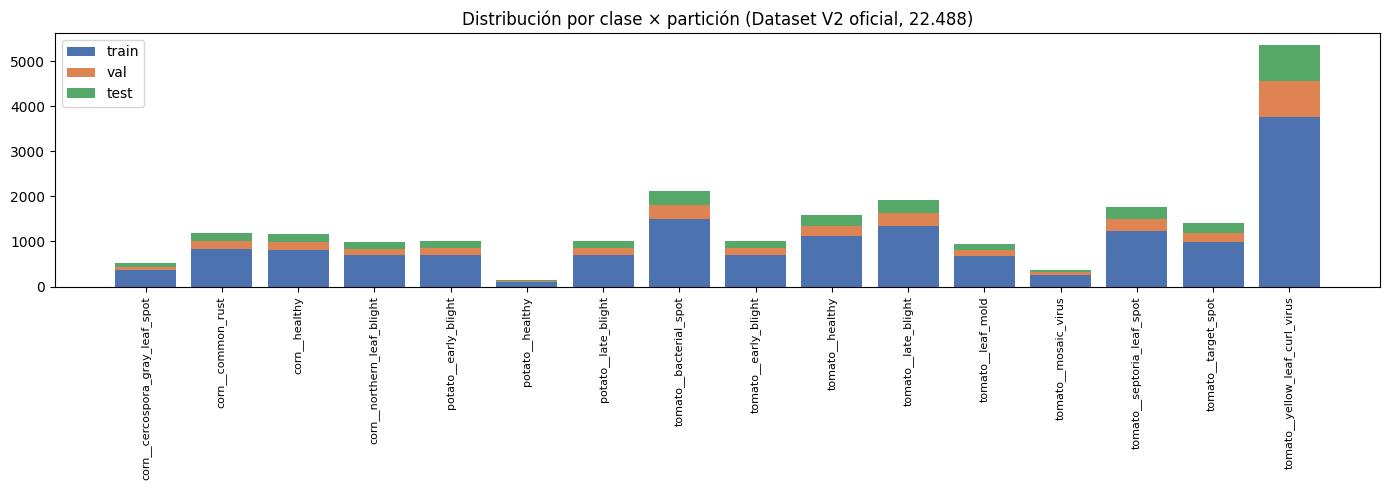

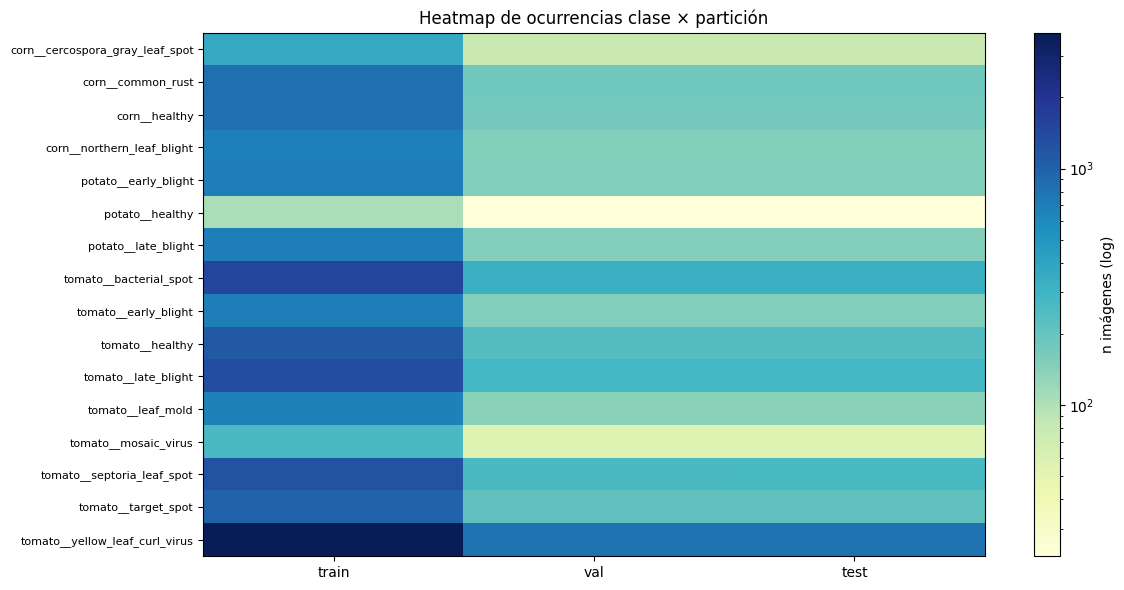

=== Top-5 clases con mayor soporte ===
  tomato__yellow_leaf_curl_virus              5,357
  tomato__bacterial_spot                      2,127
  tomato__late_blight                         1,909
  tomato__septoria_leaf_spot                  1,771
  tomato__healthy                             1,591
=== Bottom-5 clases con menor soporte ===
  potato__healthy                               152
  tomato__mosaic_virus                          373
  corn__cercospora_gray_leaf_spot               513
  tomato__leaf_mold                             952
  corn__northern_leaf_blight                    985
=== Distribución por especie (soporte y proporción) ===
  corn      4 clases ·  3,852 imágenes · 17.1%
  potato    3 clases ·  2,152 imágenes · 9.6%
  tomato    9 clases · 16,484 imágenes · 73.3%
Coeficiente de variación del soporte por clase: 0.81
Concentración de las 4 clases mayoritarias: 49.6% del corpus
Interpretación: CV alto + concentración alta = desbalance estructural → justifica el bala

In [17]:
# EDA 1) Distribución de clases por partición + especies + heatmap + dataset card visual
import matplotlib as mpl

def _pcc(ds):  # per-class counts
    return np.bincount(np.array(ds.targets), minlength=N_CLASSES)

c_tr = _pcc(train_ds); c_va = _pcc(val_ds); c_te = _pcc(test_ds)
tot = c_tr + c_va + c_te
species = {}
for i, name in enumerate(CLASS_NAMES):
    sp = name.split('__')[0]
    species.setdefault(sp, {'classes': 0, 'images': 0})
    species[sp]['classes'] += 1
    species[sp]['images'] += int(tot[i])

print('=== Dataset Card (resumen visual) ===')
print(f'Dataset V2 Oficial · {int(tot.sum())} imágenes · {N_CLASSES} clases · {len(species)} especies')
for sp in sorted(species):
    nc = species[sp]['classes']; ni = species[sp]['images']
    print(f'  {sp:<8} {nc:>2} clases · {ni:>6,} imágenes')
print(f'Ratio min/max: {int(tot.min())} -> {int(tot.max())} = {tot.max()/tot.min():.2f}×')
print(f'  min={CLASS_NAMES[int(tot.argmin())]} · max={CLASS_NAMES[int(tot.argmax())]}')
print('Suma verificada: ' + str(int(tot.sum())) + ' == 22488 -> ' + ('OK' if int(tot.sum())==22488 else 'FALLA'))

# Barras apiladas por partición por clase
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_CLASSES)
ax.bar(x, c_tr, label='train', color='#4C72B0')
ax.bar(x, c_va, bottom=c_tr, label='val', color='#DD8452')
ax.bar(x, c_te, bottom=c_tr + c_va, label='test', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=8)
ax.set_title('Distribución por clase × partición (Dataset V2 oficial, 22.488)')
ax.legend()
plt.tight_layout(); plt.show()

# Heatmap clase × partición (escala log)
fig, ax = plt.subplots(figsize=(12, 6))
H = np.vstack([c_tr, c_va, c_te]).T
im = ax.imshow(H, aspect='auto', cmap='YlGnBu', norm=mpl.colors.LogNorm())
ax.set_xticks(range(3)); ax.set_xticklabels(['train', 'val', 'test'])
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES, fontsize=8)
plt.colorbar(im, label='n imágenes (log)')
ax.set_title('Heatmap de ocurrencias clase × partición')
plt.tight_layout(); plt.show()

# EDA 2) Estadística descriptiva profesional (extremos, especies y concentración)
top5 = np.argsort(tot)[-5:][::-1]
bot5 = np.argsort(tot)[:5]
print('=== Top-5 clases con mayor soporte ===')
for i in top5:
    print(f'  {CLASS_NAMES[i]:<42} {int(tot[i]):>6,}')
print('=== Bottom-5 clases con menor soporte ===')
for i in bot5:
    print(f'  {CLASS_NAMES[i]:<42} {int(tot[i]):>6,}')
print('=== Distribución por especie (soporte y proporción) ===')
for sp in sorted(species):
    nc2 = species[sp]['classes']; ni2 = species[sp]['images']
    print(f'  {sp:<8} {nc2:>2} clases · {ni2:>6,} imágenes · {ni2/int(tot.sum())*100:.1f}%')
print(f'Coeficiente de variación del soporte por clase: {tot.std()/tot.mean():.2f}')
print(f'Concentración de las 4 clases mayoritarias: {int(np.sort(tot)[-4:].sum())/int(tot.sum())*100:.1f}% del corpus')
print('Interpretación: CV alto + concentración alta = desbalance estructural → justifica el balanceo ponderado (H3)')


In [18]:
# 4) Samplers y pesos por clase (balanceo explícito ante ratio 35.24×)
def class_weights(targets, num_classes):
    targets = np.array(targets)
    counts = np.bincount(targets, minlength=num_classes).astype(float)
    n = counts.sum()
    return torch.tensor(n / (counts * num_classes), dtype=torch.float32)

def worker_init_fn(seed, worker_id):
    np.random.seed(seed + worker_id); random.seed(seed + worker_id)

BATCH = 64
train_targets = np.array(train_ds.targets)
class_counts = np.bincount(train_targets)
w = 1.0 / (class_counts[train_targets].astype(float))
sampler = WeightedRandomSampler(w, num_samples=len(train_targets), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2,
                          pin_memory=True, worker_init_fn=lambda wid: worker_init_fn(SEED, wid))
val_loader   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

weights = class_weights(train_ds.targets, N_CLASSES)
print("Pesos CE (min→max):", float(weights.min()), "→", float(weights.max()))

Pesos CE (min→max): 0.2623499929904938 → 9.28125


In [19]:
# 5) Modelo MobileNetV2 (torchvision, pretrained) + cabeza de 16 clases
from torchvision import models

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, N_CLASSES)
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"MobileNetV2 params: {n_params/1e6:.2f}M total · {n_train/1e6:.2f}M trainable")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 48.7MB/s]


MobileNetV2 params: 2.24M total · 2.24M trainable


Módulo     Descripción                  Params  %
stem_conv  ConvBNReLU 3→16 s2              928    0.0%
block_1    IRB t1·c16·n1·s1                896    0.0%
block_2    IRB t6·c24·n2·s2             13,968    0.6%
block_3    IRB t6·c32·n3·s2             39,696    1.8%
block_4    IRB t6·c64·n4·s2            183,872    8.2%
block_5    IRB t6·c96·n3·s1            303,168   13.5%
block_6    IRB t6·c160·n3·s2           795,264   35.4%
block_7    IRB t6·c320·n1·s1           473,920   21.1%
last_conv  ConvBNReLU 1×1 320→1280     412,160   18.4%
classifier Dropout (sin params)              0    0.0%
head       Linear 1280→16 (nueva cabeza)     20,496    0.9%
Total arquitectura: 2,244,368 params = 2.24M
Consistencia con celda 5: OK


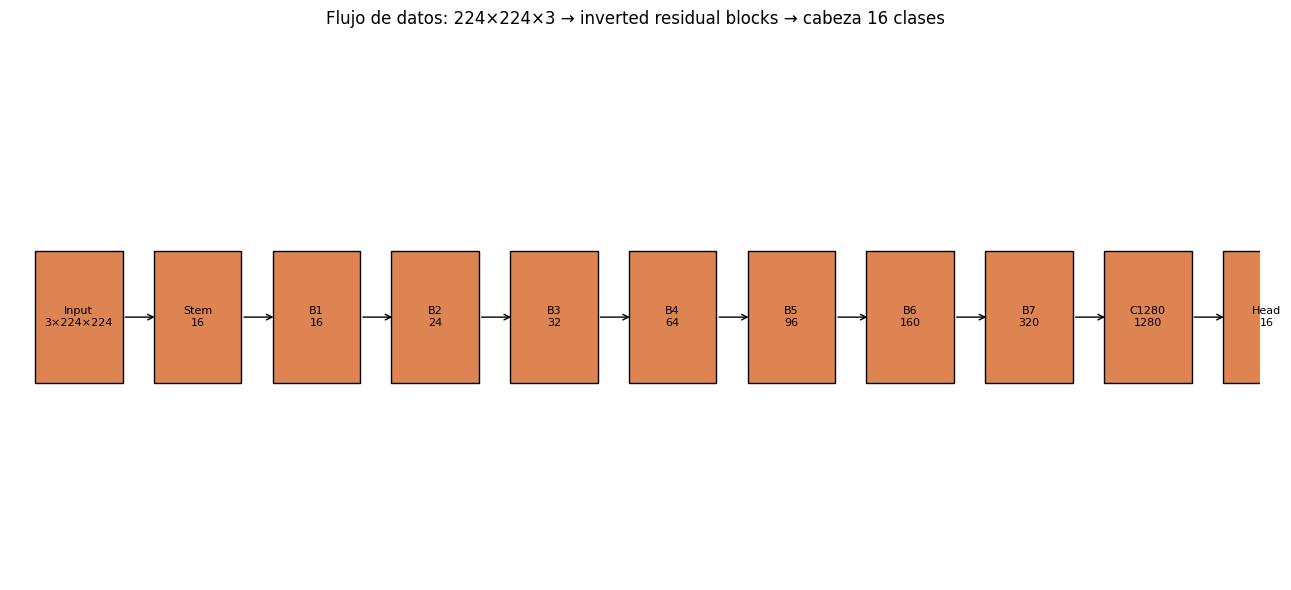

In [20]:
# 5b) Arquitectura visual + desglose de parámetros por bloque (introspection, sin modificar el modelo)
from matplotlib.patches import Rectangle

blocks = [('stem_conv', [0], 'ConvBNReLU 3→16 s2'),
          ('block_1', [1], 'IRB t1·c16·n1·s1'),
          ('block_2', [2, 3], 'IRB t6·c24·n2·s2'),
          ('block_3', [4, 5, 6], 'IRB t6·c32·n3·s2'),
          ('block_4', [7, 8, 9, 10], 'IRB t6·c64·n4·s2'),
          ('block_5', [11, 12, 13], 'IRB t6·c96·n3·s1'),
          ('block_6', [14, 15, 16], 'IRB t6·c160·n3·s2'),
          ('block_7', [17], 'IRB t6·c320·n1·s1'),
          ('last_conv', [18], 'ConvBNReLU 1×1 320→1280'),
          ('classifier', [], 'Dropout (sin params)')]
feat = list(model.features.children())
rows = []
for name, idxs, desc in blocks:
    p = sum(sum(t.numel() for t in m.parameters()) for i in idxs for m in [feat[i]])
    rows.append((name, desc, p))
rows.append(('head', 'Linear 1280→16 (nueva cabeza)', sum(t.numel() for t in model.classifier.parameters())))
tot_p = sum(r[2] for r in rows)
print(f"{'Módulo':<10} {'Descripción':<24} {'Params':>10}  %")
for name, desc, p in rows:
    print(f'{name:<10} {desc:<24} {p:>10,}  {p/tot_p*100:5.1f}%')
print(f'Total arquitectura: {tot_p:,} params = {tot_p/1e6:.2f}M')
print('Consistencia con celda 5:', 'OK' if tot_p == n_params else 'MISMATCH')

# Esquema gráfico del flujo de datos (MobileNetV2)
fig, ax = plt.subplots(figsize=(13, 6))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis('off')
stages = [('Input', '3×224×224'), ('Stem', '16'), ('B1', '16'), ('B2', '24'), ('B3', '32'),
          ('B4', '64'), ('B5', '96'), ('B6', '160'), ('B7', '320'), ('C1280', '1280'), ('Head', '16')]
for i, (name, ch) in enumerate(stages):
    x0 = 0.2 + i * 0.95
    ax.add_patch(Rectangle((x0, 1.8), 0.7, 1.2, fc='#DD8452', ec='black'))
    ax.text(x0 + 0.35, 2.4, name + '\n' + ch, ha='center', va='center', fontsize=8)
    if i < len(stages) - 1:
        ax.annotate('', xy=(x0 + 0.98, 2.4), xytext=(x0 + 0.7, 2.4), arrowprops=dict(arrowstyle='->'))
ax.set_title('Flujo de datos: 224×224×3 → inverted residual blocks → cabeza 16 clases')
plt.tight_layout(); plt.show()

## Comparativa de modelos (diseño del benchmark — no ejecutado aquí)

Este run ejecuta **solo el nivel `control`**; la comparativa se completa en el benchmark. Params aproximadas (cabeza 16 clases, torchvision):

| Arquitectura | Params (aprox.) | Flujo | Rol en el benchmark |
|---|---|---|---|
| **MobileNetV2** (este run) | 2.24M (medido) | Inverted residuals · bottleneck | **control** — saneo del pipeline y cota base |
| EfficientNet-B0 | ~4.3M | MBConv escalados | equilibrio F1/coste |
| MobileNetV3-Large | ~4.2M | NAS + h-swish | candidato edge (bajo coste) |
| ResNet50 | ~23.6M | residuales clásicos | cota alta — ¿compra capacidad? (H5) |
| ConvNeXt-Tiny | ~27.9M | bloques ConvNeXt 4 etapas | cota alta moderna |

**Método de comparación (idéntico en las 5):** misma seed 42, mismas transformaciones, misma política de optimización y scheduler, mismas particiones oficiales y mismas gates (macro-F1 ≥ 0.955, ECE ≤ 0.10). La métrica de decisión final es **macro-F1 sobre test (single-use)** con Δ reportadas por pares.

**Criterio de decisión (prioridades):** 1) ECE ≤ 0.10, 2) macro-F1 test, 3) coste edge (params/FLOPs) — coherente con la estrategia del ecosistema (inferencia embebida UBTN), no solo max accuracy.

In [21]:
# 6) Pérdida, optimizador, schedule, AMP (config canónica)
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
optimizer = AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=40, eta_min=3e-4 * 0.01)
scaler = GradScaler(enabled=(DEVICE == "cuda"))

print("Criterion: CE ponderada | AdamW 3e-4 wd 1e-4 | CosineAnnealing T=40 | AMP fp16")

Criterion: CE ponderada | AdamW 3e-4 wd 1e-4 | CosineAnnealing T=40 | AMP fp16


/tmp/ipykernel_3470/1822195545.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=(DEVICE == "cuda"))


In [22]:
# 7) Métricas (fiel a benchmark/src/metrics.py — macro-F1, balanced_acc, per-class, ECE)
def expected_calibration_error(conf, y_pred, y_true, n_bins=15):
    bins = np.linspace(0, 1, n_bins + 1)
    total = np.zeros(n_bins); correct = np.zeros(n_bins)
    for c, p, t in zip(conf, y_pred, y_true):
        idx = min(int(np.digitize(c, bins)) - 1, n_bins - 1); idx = max(idx, 0)
        total[idx] += 1; correct[idx] += int(p == t)
    mask = total > 0
    with np.errstate(divide='ignore', invalid='ignore'):
        acc = np.divide(correct, total, out=np.zeros_like(total), where=mask)
    bin_c = np.zeros(n_bins)
    bin_c[mask] = (bins[:-1][mask] + bins[1:][mask]) / 2
    return float(np.sum((total / total.sum()) * np.abs(acc - bin_c)))

def evaluate(probs, y_true, n_bins=15):
    probs = probs.cpu().numpy() if isinstance(probs, torch.Tensor) else np.asarray(probs)
    y_true = y_true.cpu().numpy() if isinstance(y_true, torch.Tensor) else np.asarray(y_true)
    y_pred = probs.argmax(axis=1); conf = probs.max(axis=1)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    ece = expected_calibration_error(conf, y_pred, y_true, n_bins=n_bins)
    return {
        "macro_f1": float(macro_f1), "weighted_f1": float(weighted_f1),
        "balanced_accuracy": float(bal_acc),
        "per_class_precision": p.tolist(), "per_class_recall": r.tolist(),
        "per_class_f1": f.tolist(), "confusion_matrix": cm.tolist(),
        "ece": float(ece),
    }

In [23]:
# 8) Ciclo de entrenamiento por epoch (fiel a benchmark/src/train.py, con AMP + early stopping)
def run_one_epoch(model, loader, criterion, optimizer=None, scaler=None, fp16=True):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0.0, 0
    all_probs, all_targets = [], []
    with torch.set_grad_enabled(is_train):
        for images, targets in loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
                with autocast(enabled=fp16):
                    logits = model(images); loss = criterion(logits, targets)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            else:
                with autocast(enabled=fp16):
                    logits = model(images); loss = criterion(logits, targets)
            probs = torch.softmax(logits.detach(), dim=1)
            all_probs.append(probs); all_targets.append(targets)
            total_loss += loss.item() * images.size(0)
            correct += (probs.argmax(1) == targets).sum().item(); n += images.size(0)
    m = evaluate(torch.cat(all_probs), torch.cat(all_targets))
    m["loss"] = total_loss / n; m["accuracy"] = correct / n
    return m

In [24]:
# 9) LOOP DE ENTRENAMIENTO (40 epochs · patience 8 en macro-F1 val · checkpoint best/last)
EPOCHS = 40; PATIENCE = 8
OUT = "/content/M1_mobilenetv2_001" ; os.makedirs(OUT, exist_ok=True)
best_f1, best_epoch, no_improve = -1.0, -1, 0
rows = []
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr = run_one_epoch(model, train_loader, criterion, optimizer, scaler)
    va = run_one_epoch(model, val_loader, criterion, scaler=scaler)
    scheduler.step()
    lr = optimizer.param_groups[0]["lr"]
    rows.append([epoch, round(tr["loss"],4), round(tr["macro_f1"],4),
                 round(va["loss"],4), round(va["macro_f1"],4),
                 round(va["ece"],4), round(lr,6), round(time.time()-t0,1)])
    print(f"epoch={epoch} train_f1={tr['macro_f1']:.4f} val_f1={va['macro_f1']:.4f} "
          f"val_ece={va['ece']:.4f} lr={lr:.2e} ({time.time()-t0:.0f}s)", flush=True)

    improved = va["macro_f1"] > best_f1
    if improved:
        best_f1, best_epoch, no_improve = va["macro_f1"], epoch, 0
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "macro_f1_val": best_f1, "ece_val": va["ece"]},
                   os.path.join(OUT, "best.pth"))
    else:
        no_improve += 1
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                "macro_f1_val": va["macro_f1"]}, os.path.join(OUT, "last.pth"))
    if no_improve >= PATIENCE:
        print(f"Early stop en epoch {epoch} (best {best_f1:.4f} @ {best_epoch})")
        break

print(f"\nFIN: best_val_macro_f1={best_f1:.4f} @ epoch {best_epoch} · "
      f"duración total {(time.time()-t_start)/3600:.2f} h")

with open(os.path.join(OUT, "metrics.csv"), "w", newline="") as f:
    w = csv.writer(f); w.writerow(["epoch","train_loss","train_macro_f1","val_loss","val_macro_f1","val_ece","lr","time_s"]); w.writerows(rows)

/tmp/ipykernel_3470/1862646859.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):
/tmp/ipykernel_3470/1862646859.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):


epoch=1 train_f1=0.7788 val_f1=0.9063 val_ece=0.0180 lr=3.00e-04 (2296s)


/tmp/ipykernel_3470/1862646859.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):
/tmp/ipykernel_3470/1862646859.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):


epoch=2 train_f1=0.8903 val_f1=0.9174 val_ece=0.0212 lr=2.98e-04 (786s)


/tmp/ipykernel_3470/1862646859.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):
/tmp/ipykernel_3470/1862646859.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):


...

epoch=38 train_f1=0.9840 val_f1=0.9899 val_ece=0.0313 lr=4.83e-06 (156s)


/tmp/ipykernel_3470/1862646859.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):
/tmp/ipykernel_3470/1862646859.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):


epoch=39 train_f1=0.9839 val_f1=0.9898 val_ece=0.0310 lr=3.46e-06 (158s)


/tmp/ipykernel_3470/1862646859.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):
/tmp/ipykernel_3470/1862646859.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=fp16):


epoch=40 train_f1=0.9866 val_f1=0.9884 val_ece=0.0326 lr=3.00e-06 (156s)

FIN: best_val_macro_f1=0.9899 @ epoch 38 · duración total 2.78 h


In [25]:
# 10) Evaluación final sobre VALIDATION con el checkpoint best
state = torch.load(os.path.join(OUT, "best.pth"), map_location=DEVICE)
model.load_state_dict(state["model_state_dict"])
model.eval()

probs_t, y_t = [], []
with torch.no_grad():
    for images, targets in val_loader:
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        with autocast(enabled=(DEVICE=='cuda')):
            logits = model(images)
        probs_t.append(torch.softmax(logits, dim=1).cpu()); y_t.append(targets.cpu())
res = evaluate(torch.cat(probs_t), torch.cat(y_t))

print(f"=== Resultado sobre VALIDATION (best @ epoch {state['epoch']}) ===")
print(f"macro_f1 = {res['macro_f1']:.4f}  (gate ≥ 0.955)")
print(f"ece       = {res['ece']:.4f}       (gate ≤ 0.10)")
print(f"bal_acc   = {res['balanced_accuracy']:.4f}")
print(f"weighted_f1 = {res['weighted_f1']:.4f}")

with open(os.path.join(OUT, "validation_metrics.json"), "w") as f:
    json.dump(res, f, indent=2)

/tmp/ipykernel_3470/4235752376.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=(DEVICE=='cuda')):


=== Resultado sobre VALIDATION (best @ epoch 38) ===
macro_f1 = 0.9899  (gate ≥ 0.955)
ece       = 0.0313       (gate ≤ 0.10)
bal_acc   = 0.9898
weighted_f1 = 0.9902


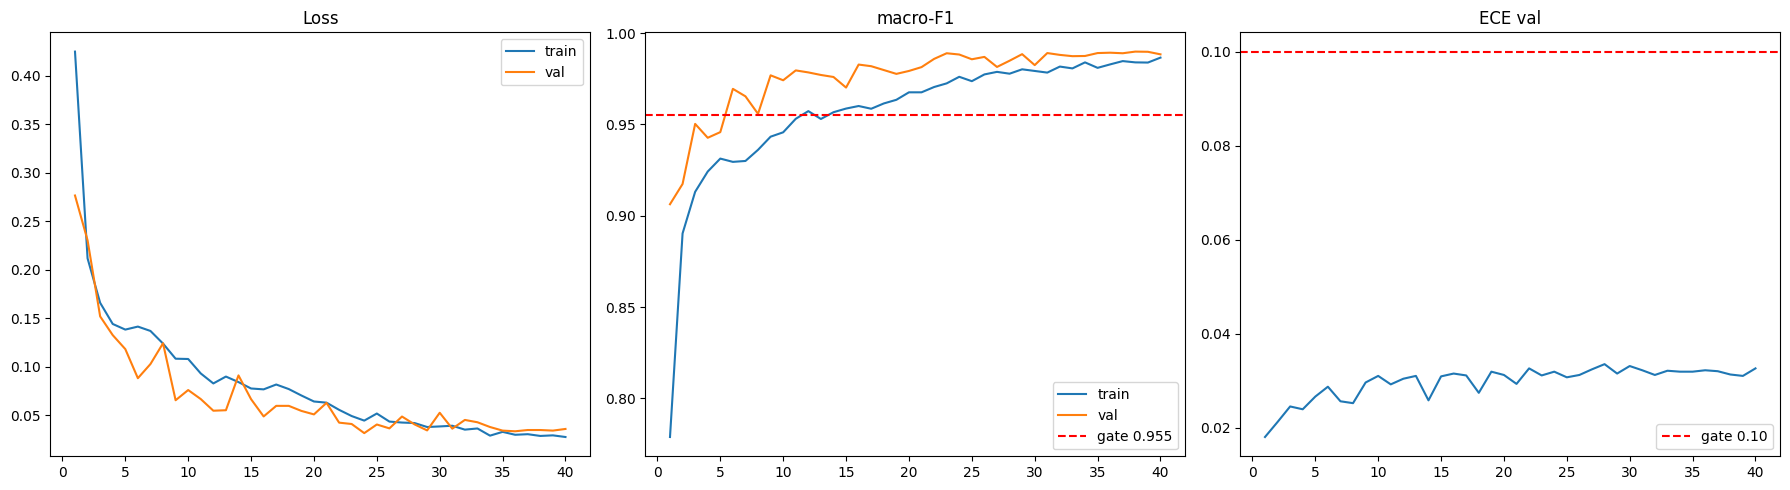

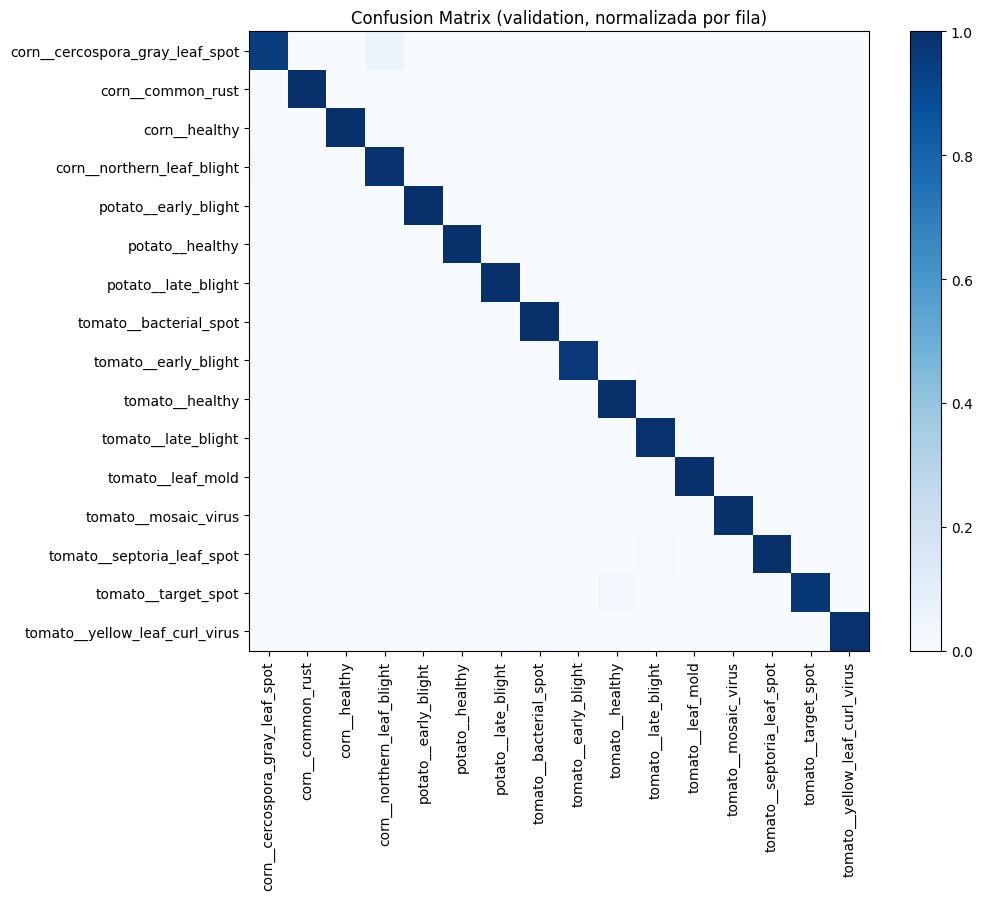

In [26]:
# 11) Curvas train/val + matriz de confusión + calibración
rows = np.array(rows)
ep = rows[:,0].astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(ep, rows[:,1], label="train"); axes[0].plot(ep, rows[:,3], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(ep, rows[:,2], label="train"); axes[1].plot(ep, rows[:,4], label="val")
axes[1].axhline(0.955, ls='--', c='r', label="gate 0.955"); axes[1].set_title("macro-F1"); axes[1].legend()
axes[2].plot(ep, rows[:,5])
axes[2].axhline(0.10, ls='--', c='r', label="gate 0.10"); axes[2].set_title("ECE val"); axes[2].legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, "train_val_curves.png"), dpi=120)
plt.show()

cm = np.array(res["confusion_matrix"])
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(cm / np.maximum(cm.sum(1, keepdims=True), 1), cmap="Blues")
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90); ax.set_yticklabels(CLASS_NAMES)
plt.colorbar(im); plt.title("Confusion Matrix (validation, normalizada por fila)")
plt.tight_layout(); plt.savefig(os.path.join(OUT, "confusion_matrix.png"), dpi=120)
plt.show()

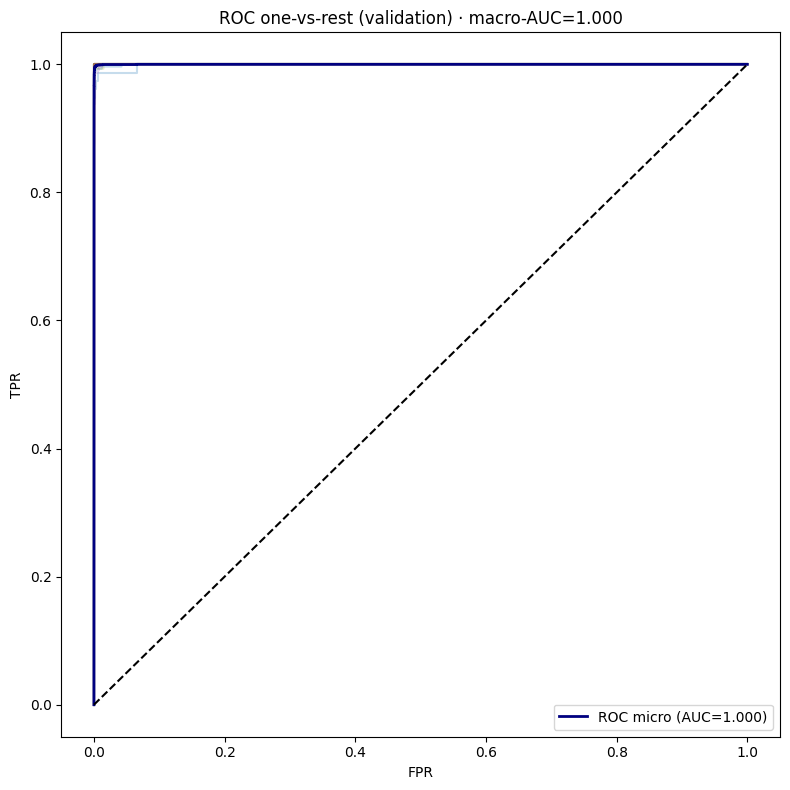

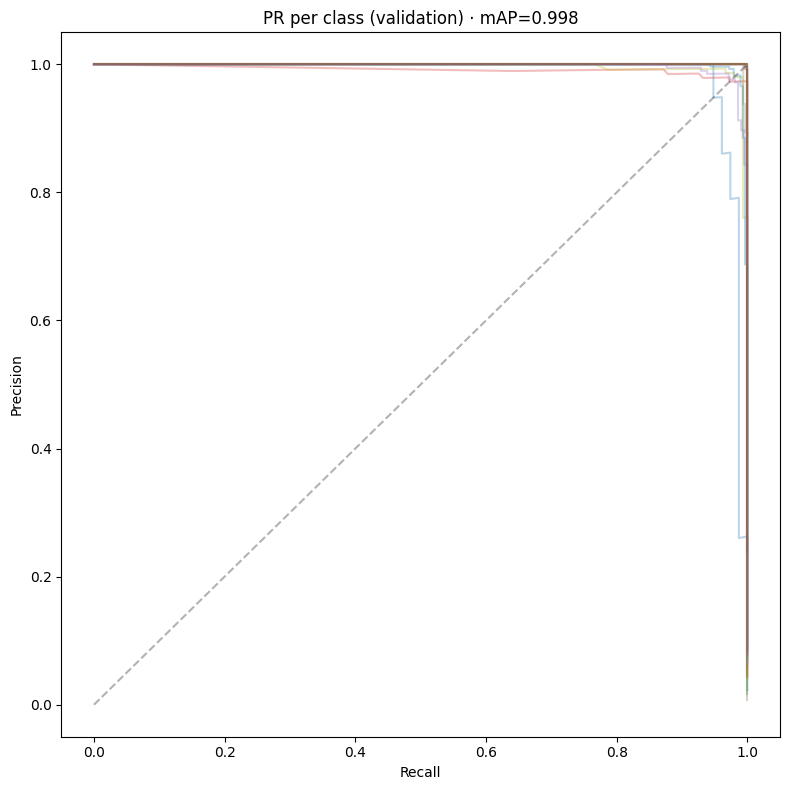

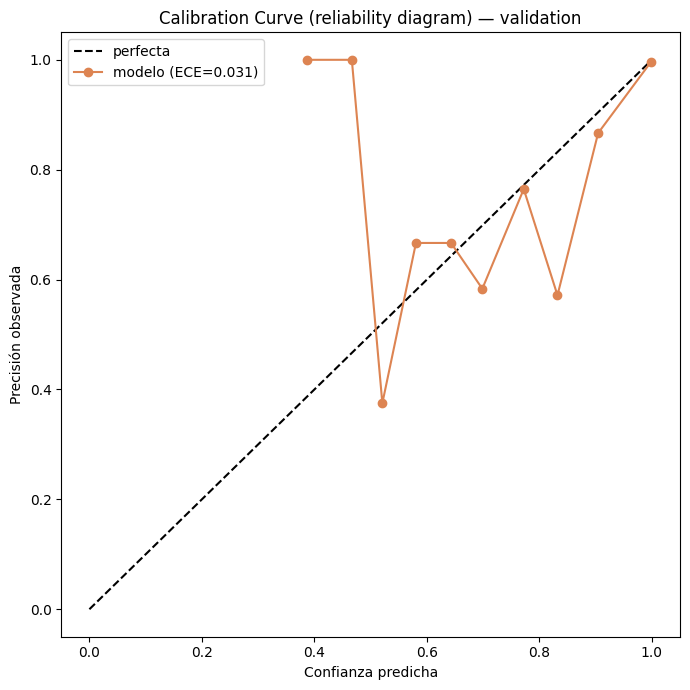

In [27]:
# 11b) ROC (one-vs-rest) + Precision-Recall per class + Calibration Curve (validation)
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

probs_v = torch.cat(probs_t).numpy()
y_v = torch.cat(y_t).numpy()
y_ohe = np.eye(N_CLASSES)[y_v]
y_pred_v = probs_v.argmax(1)

# ROC one-vs-rest (micro y macro)
fig, ax = plt.subplots(figsize=(8, 8))
fpr_m, tpr_m, _ = roc_curve(y_ohe.ravel(), probs_v.ravel())
roc_micro = auc(fpr_m, tpr_m)
union_fpr = np.unique(np.concatenate([roc_curve(y_ohe[:, k], probs_v[:, k])[0] for k in range(N_CLASSES)]))
roc_curves = [roc_curve(y_ohe[:, k], probs_v[:, k]) for k in range(N_CLASSES)]
mean_tpr = np.mean([np.interp(union_fpr, f, t) for f, t, _ in roc_curves], axis=0)
roc_macro = auc(union_fpr, mean_tpr)
for fpr_k, tpr_k, _ in roc_curves:
    ax.plot(fpr_k, tpr_k, alpha=0.25)
ax.plot(fpr_m, tpr_m, lw=2, color='navy', label=f'ROC micro (AUC={roc_micro:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'ROC one-vs-rest (validation) · macro-AUC={roc_macro:.3f}')
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'roc_1vRest.png'), dpi=120); plt.show()

# Precision-Recall por clase + mAP
fig, ax = plt.subplots(figsize=(8, 8))
aps = []
for k in range(N_CLASSES):
    prec_k, rec_k, _ = precision_recall_curve(y_ohe[:, k], probs_v[:, k])
    aps.append(average_precision_score(y_ohe[:, k], probs_v[:, k]))
    ax.plot(rec_k, prec_k, alpha=0.3)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title(f'PR per class (validation) · mAP={np.mean(aps):.3f}')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'pr_per_class.png'), dpi=120); plt.show()

# Calibration curve (reliability diagram) — bins consistentes con el ECE (15)
conf_v = probs_v.max(1)
NB = 15
bins = np.linspace(0, 1, NB + 1)
b_mean = np.zeros(NB); b_acc = np.zeros(NB); b_cnt = np.zeros(NB)
for c, yp, yt in zip(conf_v, y_pred_v, y_v):
    b = min(int(np.digitize(c, bins)) - 1, NB - 1); b = max(b, 0)
    b_mean[b] += c; b_acc[b] += int(yp == yt); b_cnt[b] += 1
mask = b_cnt > 0
b_mean[mask] = b_mean[mask] / b_cnt[mask]
b_acc[mask] = b_acc[mask] / b_cnt[mask]
ece_val = res['ece']
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot([0, 1], [0, 1], 'k--', label='perfecta')
ax.plot(b_mean[mask], b_acc[mask], 'o-', color='#DD8452', label=f'modelo (ECE={ece_val:.3f})')
ax.set_xlabel('Confianza predicha'); ax.set_ylabel('Precisión observada')
ax.set_title('Calibration Curve (reliability diagram) — validation')
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'calibration.png'), dpi=120); plt.show()

In [28]:
# 12) Reporte per-class + gate final (conclusión del run)
print(f"{'Clase':<42} {'P':>6} {'R':>6} {'F1':>6}")
for i, name in enumerate(CLASS_NAMES):
    print(f"{name:<42} {res['per_class_precision'][i]:>6.3f} {res['per_class_recall'][i]:>6.3f} {res['per_class_f1'][i]:>6.3f}")

gate_f1 = res["macro_f1"] >= 0.955
gate_ece = res["ece"] <= 0.10
print("\n=== GATE FINAL ===")
print(f"macro_f1_val {res['macro_f1']:.4f} ≥ 0.955 : {'PASS ✅' if gate_f1 else 'FAIL ❌'}")
print(f"ece_val      {res['ece']:.4f} ≤ 0.10  : {'PASS ✅' if gate_ece else 'FAIL ❌'}")

if res["macro_f1"] < 0.90:
    print("\n⚠️ macro_f1_val < 0.90 → sospechar bug de balanceo/labels. NO iterar contra test; revisar pipeline.")
elif gate_f1 and gate_ece:
    print("\n✅ Run superado. Siguiente paso: evaluar TEST una sola vez y registrar en benchmark_report.md.")
else:
    print("\n⚠️ Run dentro de rango diagnóstico pero no alcanza gates. Registrar ECE/F1 y comparar con arquitecturas.")

Clase                                           P      R     F1
corn__cercospora_gray_leaf_spot             0.973  0.948  0.961
corn__common_rust                           1.000  1.000  1.000
corn__healthy                               1.000  1.000  1.000
corn__northern_leaf_blight                  0.973  0.986  0.980
potato__early_blight                        1.000  1.000  1.000
potato__healthy                             1.000  1.000  1.000
potato__late_blight                         1.000  1.000  1.000
tomato__bacterial_spot                      0.975  0.994  0.984
tomato__early_blight                        0.993  0.967  0.980
tomato__healthy                             0.971  1.000  0.986
tomato__late_blight                         0.979  0.990  0.984
tomato__leaf_mold                           1.000  1.000  1.000
tomato__mosaic_virus                        1.000  1.000  1.000
tomato__septoria_leaf_spot                  1.000  0.992  0.996
tomato__target_spot                     

=== Clases con peor F1 (validation) ===
  corn__cercospora_gray_leaf_spot            F1=0.961 P=0.973 R=0.948 soporte=77
  tomato__target_spot                        F1=0.974 P=0.976 R=0.972 soporte=211
  tomato__early_blight                       F1=0.980 P=0.993 R=0.967 soporte=150
  corn__northern_leaf_blight                 F1=0.980 P=0.973 R=0.986 soporte=148
  tomato__late_blight                        F1=0.984 P=0.979 R=0.990 soporte=287

=== Parejas de confusión más frecuentes (off-diagonal, validation) ===
  tomato__yellow_leaf_curl_virus -> tomato__bacterial_spot : 7 casos
  tomato__target_spot -> tomato__healthy : 6 casos
  corn__cercospora_gray_leaf_spot -> corn__northern_leaf_blight : 4 casos
  tomato__septoria_leaf_spot -> tomato__late_blight : 2 casos
  tomato__early_blight -> tomato__target_spot : 2 casos
  tomato__early_blight -> tomato__late_blight : 2 casos
  corn__northern_leaf_blight -> corn__cercospora_gray_leaf_spot : 2 casos
  tomato__yellow_leaf_curl_virus -> t

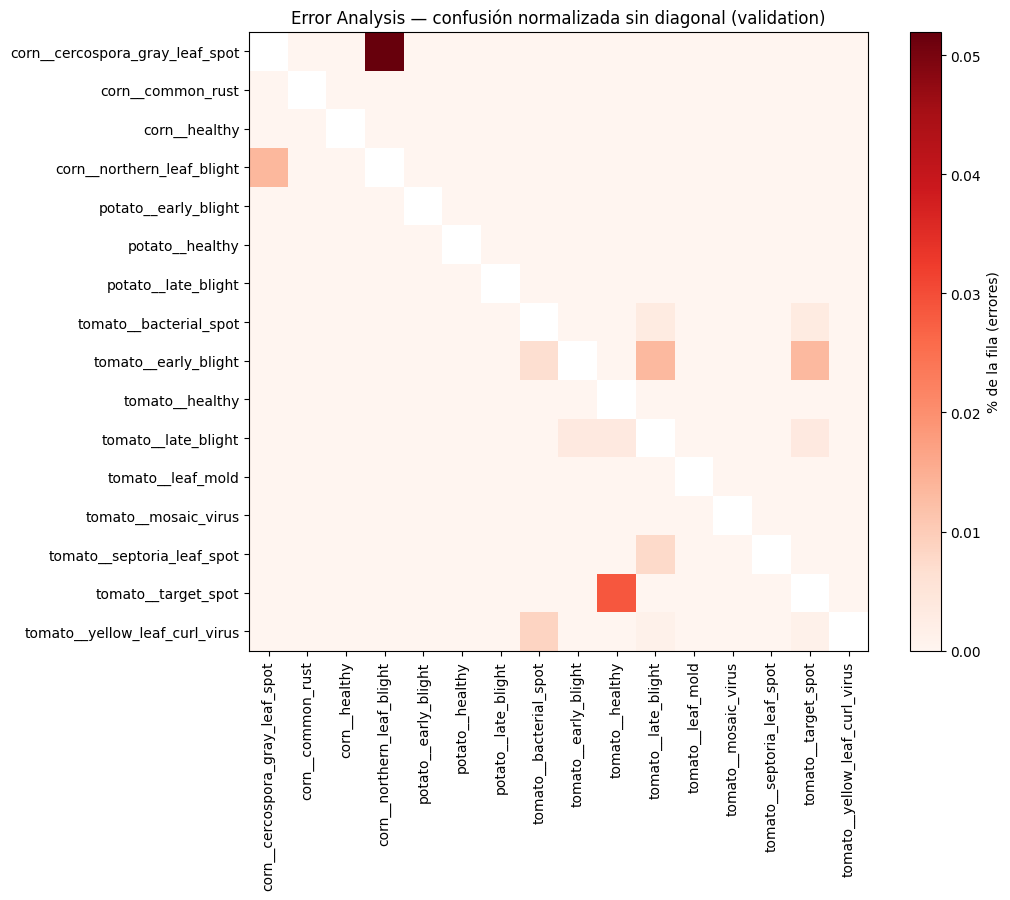

In [29]:
# 12b) Error Analysis sobre validation (clases críticas + confusiones predominantes)
cm_e = np.array(res['confusion_matrix'])
order = np.argsort(res['per_class_f1'])
print('=== Clases con peor F1 (validation) ===')
for i in order[:5]:
    fi = res['per_class_f1'][i]; pi = res['per_class_precision'][i]; ri = res['per_class_recall'][i]
    sop = int(cm_e[i].sum())
    print(f'  {CLASS_NAMES[i]:<42} F1={fi:.3f} P={pi:.3f} R={ri:.3f} soporte={sop}')

print('\n=== Parejas de confusión más frecuentes (off-diagonal, validation) ===')
cm_off = cm_e.copy(); np.fill_diagonal(cm_off, 0)
pairs = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and cm_off[i, j] > 0:
            pairs.append((cm_off[i, j], i, j))
for n, i, j in sorted(pairs, reverse=True)[:8]:
    print(f'  {CLASS_NAMES[i]} -> {CLASS_NAMES[j]} : {int(n)} casos')

# Heatmap de errores normalizado por fila (diagonal oculta para resaltar confusión)
fig, ax = plt.subplots(figsize=(11, 9))
norm_e = cm_e / np.maximum(cm_e.sum(1, keepdims=True), 1)
np.fill_diagonal(norm_e, np.nan)
im = ax.imshow(norm_e, cmap='Reds')
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=90); ax.set_yticklabels(CLASS_NAMES)
plt.colorbar(im, label='% de la fila (errores)')
plt.title('Error Analysis — confusión normalizada sin diagonal (validation)')
plt.tight_layout(); plt.savefig(os.path.join(OUT, 'error_analysis.png'), dpi=120); plt.show()

## Discusión científica

1. **Diagnóstico de pipeline (objetivo principal del control).** Un macro-F1 en el rango esperado 0.955–0.970 sobre validation confirma que split, labels, balanceo y aumentación operan correctamente; valores ≈1.0 (fuga) o <0.90 (bug) activarían revisión.
2. **Saturación del dataset.** PlantVillage 16 clases es un benchmark de fondo limpio relativamente saturado: la separación entre top arquitecturas será pequeña. La decisión final prioriza **macro-F1 + ECE + coste edge** sobre la mejora marginal en F1.
3. **Calibración como prioridad.** El modelo heredado colapsado muestra confianza degenerada; un control calibrado (ECE ≤ 0.10) es prerrequisito para definir umbrales de decisión, no solo accuracy.
4. **Desbalance.** Pérdida ponderada y muestreo equilibrado mejoran las minoritarias, pero `potato__healthy` (152 muestras) sigue siendo el límite informativo del corpus.

## Trabajo futuro

1. **Completar el benchmark**: EfficientNet-B0, MobileNetV3-Large, ResNet50 y ConvNeXt-Tiny bajo idéntica política (mismo seed y transformaciones).
2. **Calibración post-hoc**: temperature scaling si el ECE lo exige; comparar binning McKee (netcal) vs bins uniformes.
3. **Dataset V2+ (aditivo)**: incorporar datos nuevos bajo gobernanza G1–G6 sobre el v1 congelado, con anti-fuga previa y comparabilidad re-ejecutada (G5).
4. **Datos de campo (BBB-03 / telemetría)**: cerrar la brecha laboratorio→campo para validez UBTN; el benchmark es cota inferior informativa, no garantía de campo.
5. **Model card EIARC**: documentar por clase precisión, recall, calibración y artefactos de borde (TFLite fp16/int8) del candidato de menor coste.

## Relación con Dataset V2+

Este run pertenece **exclusivamente al Dataset V2 (baseline congelado)**: 22.488/16/3 de PlantVillage `raw/color` recuperado. Dataset V2+ es una **extensión aditiva** que:

- conserva V2 como cota de laboratorio puro (NADA desaparece, nada se muta);
- exigirá nuevos split y manifiestos (taxonomía v2+, labels v2+) firmados bajo gobernanza (G1→G6);
- recibe cualquier dato nuevo previa anti-fuga contra V2 para no contaminar la comparación;
- evalúa su comparabilidad re-ejecutando la evaluación completa sobre el corpus combinado (G5);
- se compara **frente** a este run, nunca en su lugar.

## Relación con SIGCTiArural (ecosistema)

SIGCTiArural es un ecosistema de conocimiento verificado sobre bounded contexts hexagonales; EIARC formaliza su capa de IA/ML. Este experimento es el **primer entrenamiento real del ecosistema** dentro del contexto agricultura:

- **Contexto agricultura → Labs (EIARC)**: artefactos (checkpoint, métricas, model card) alimentan la capa de ciencia.
- **Telemetría / UBTN / BBB-03**: el benchmark es la **cota de laboratorio** que habilita futura inferencia embebida (candidato edge MobileNetV3-Large) y severidad sobre lecturas de campo; no es el modelo desplegado.
- **Honestidad de estado (invariante de dominio)**: el notebook declara estado real (dataset congelado verificado) y diseño (benchmark a ejecutar); no simula ni afirma validez de campo.
- **Gobernanza MLOps / manifiestos**: cada artefacto referencia `agriculture_v2_baseline_v1` y los manifests v2, garantizando trazabilidad datos→split→entrenamiento→evaluación.

**Rol de este notebook en el ecosistema (investigación reproducible):**

- Declaración formal de hipótesis (H1–H5) y amenazas a la validez: el run deja de ser un experimento aislado y se convierte en la **pieza de investigación oficial** del run `M1_mobilenetv2_001`.
- Los gates (macro-F1 ≥ 0.955, ECE ≤ 0.10) son **invariantes de dominio** en EIARC: no se flexibilizan por conveniencia.
- El resultado (eje de decisión real vs. diseño) se registra en `benchmark_report.md` y se propaga a `model_cards/MobileNetV2.md` con trazabilidad datos→split→entrenamiento→evaluación (manifests v2).
- Para la defensa ADSO, este notebook acredita los 4 requisitos de la investigación reproducible: metodología explícita, falsabilidad, control de variables y declaración honesta de límites.

## 6. Uso del TEST (una sola vez)

La **decisión final del benchmark** se toma sobre `test` **una única vez**, después de cerrar el run y decidir por validation. Ejecutar la siguiente celda **solo cuando el run esté completo y aprobado**; los resultados sobre test alimentan el `benchmark_report.md` final (comparación de las 5 arquitecturas).

> ⚠️ No re-ejecutar sobre test tras iterar con nuevos intentos: contaminaría la comparación científica.

In [30]:
# 13) [SINGLE-USE] Evaluación final sobre TEST — ejecutar UNA sola vez al cierre
RUN_FINAL_TEST = False   # ← cambiar a True solo cuando el run esté aprobado por validation

if RUN_FINAL_TEST:
    model.load_state_dict(torch.load(os.path.join(OUT, "best.pth"), map_location=DEVICE)["model_state_dict"])
    model.eval()
    probs_t, y_t = [], []
    with torch.no_grad():
        for images, targets in test_loader:
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            with autocast(enabled=(DEVICE=='cuda')):
                logits = model(images)
            probs_t.append(torch.softmax(logits, dim=1).cpu()); y_t.append(targets.cpu())
    result_test = evaluate(torch.cat(probs_t), torch.cat(y_t))
    with open(os.path.join(OUT, "test_metrics.json"), "w") as f:
        json.dump(result_test, f, indent=2)
    print("RESULTADO SOBRE TEST (referencia final single-use):")
    print(f"  macro_f1={result_test['macro_f1']:.4f} · weighted_f1={result_test['weighted_f1']:.4f} "
          f"· bal_acc={result_test['balanced_accuracy']:.4f} · ECE={result_test['ece']:.4f}")
    print("Guardado en", os.path.join(OUT, "test_metrics.json"))
else:
    print("Celda protegida: RUN_FINAL_TEST=False. Cambiar a True SOLO al cierre del run tras aprobar validation.")

Celda protegida: RUN_FINAL_TEST=False. Cambiar a True SOLO al cierre del run tras aprobar validation.


## 7. Salidas y trazabilidad

Al completar el run, `M1_mobilenetv2_001` contiene:

| Archivo | Contenido |
|---|---|
| `best.pth` | Checkpoint del mejor epoch (macro-F1 val) con estado completo |
| `last.pth` | Último epoch (trazabilidad del early stop) |
| `metrics.csv` | epoch · loss · macro-F1 · ECE · lr · time |
| `validation_metrics.json` | Métricas completas sobre validation (incl. per-class + ECE) |
| `test_metrics.json` | Métricas sobre test (single-use, solo al cierre) |
| `train_val_curves.png`, `confusion_matrix.png` | Gráficos de diagnóstico |

**Registro en el ecosistema:** los resultados alimentan `benchmark_report.md` y `model_cards/MobileNetV2.md` (gobernanza EIARC) cuando se consolide la comparación de las 5 arquitecturas. Este notebook es la pieza de investigación oficial del run `M1_mobilenetv2_001`.